In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
#pipiline del code para un ML
#Dataset crudo
#        ↓
#Merge
#        ↓
#Target binario
#        ↓
#Selección de features
#        ↓
#Train/Test split
#        ↓
#Modelo base
#        ↓
#Evaluación

In [7]:
events = pd.read_csv("C:/Users/franm/Desktop/github/event_details.csv")
fights = pd.read_csv("C:/Users/franm/Desktop/github/fight_details.csv")
fighters = pd.read_csv("C:/Users/franm/Desktop/github/fighter_details.csv")
ufc = pd.read_csv("C:/Users/franm/Desktop/github/UFC.csv")

In [8]:
events.head()

,event_id,fight_id,date,location,winner,winner_id
0,6e380a4d73ab4f0e,5bcd8abf6da01dae,"September 06, 2025","Paris, Ile-de-France, France",Nassourdine Imavov,881bf86d4cba8578
1,6e380a4d73ab4f0e,d14fea43712707f0,"September 06, 2025","Paris, Ile-de-France, France",Benoit Saint Denis,c2299ec916bc7c56
2,6e380a4d73ab4f0e,0149e875b31e57f8,"September 06, 2025","Paris, Ile-de-France, France",Modestas Bukauskas,476fe566d2df676e
3,6e380a4d73ab4f0e,69b31593175f77ec,"September 06, 2025","Paris, Ile-de-France, France",Mason Jones,f6ad6a1e4d600e0d
4,6e380a4d73ab4f0e,a47123ae6e048f11,"September 06, 2025","Paris, Ile-de-France, France",Axel Sola,1d2d98ddd05b38fb


In [9]:
fights.head()

,event_name,event_id,fight_id,r_name,r_id,b_name,b_id,division,title_fight,method,...,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per
0,UFC Fight Night: Imavov vs. Borralho,6e380a4d73ab4f0e,d14fea43712707f0,Benoit Saint Denis,c2299ec916bc7c56,Mauricio Ruffy,9c393e836a852f30,lightweight,0,Submission,...,NaN,0.0,0.0,NaN,80.0,20.0,0.0,100.0,0.0,0.0
1,UFC Fight Night: Imavov vs. Borralho,6e380a4d73ab4f0e,5bcd8abf6da01dae,Nassourdine Imavov,881bf86d4cba8578,Caio Borralho,4126a78111c0855a,middleweight,0,Decision - Unanimous,...,100.0,0.0,0.0,NaN,59.0,21.0,19.0,89.0,10.0,0.0
2,UFC Fight Night: Imavov vs. Borralho,6e380a4d73ab4f0e,0149e875b31e57f8,Modestas Bukauskas,476fe566d2df676e,Paul Craig,eabf206b162b3b83,light heavyweight,0,KO/TKO,...,100.0,0.0,0.0,NaN,0.0,33.0,66.0,83.0,16.0,0.0
3,UFC Fight Night: Imavov vs. Borralho,6e380a4d73ab4f0e,69b31593175f77ec,Bolaji Oki,4bdedbdeedff7d1d,Mason Jones,f6ad6a1e4d600e0d,lightweight,0,KO/TKO,...,67.0,32.0,49.0,65.0,91.0,3.0,5.0,40.0,3.0,56.0
4,UFC Fight Night: Imavov vs. Borralho,6e380a4d73ab4f0e,a47123ae6e048f11,Axel Sola,1d2d98ddd05b38fb,Rhys McKee,f748267c4ab6c127,welterweight,0,KO/TKO,...,53.0,0.0,0.0,NaN,81.0,18.0,0.0,69.0,30.0,0.0


In [10]:
fighters.head()

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,dob,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg
0,8f382b3baa954d2a,Jessica Aguilar,Jag,20,8,0,160.02,52.16,160.02,Orthodox,"May 08, 1982",4.93,50,7.19,53,0.94,25,50,0.2
1,483a953b18d73bb3,Deron Winn,NaN,7,3,0,167.64,83.91,177.80,Orthodox,"Jun 13, 1989",4.55,44,6.21,46,4.28,52,40,0.0
2,232c582f29f8f65e,Gegard Mousasi,NaN,42,6,2,187.96,83.91,193.04,Orthodox,"Aug 01, 1985",3.75,50,1.21,68,1.59,60,59,1.1
3,236a37d96d476164,Mike Pierce,NaN,17,7,0,172.72,77.11,180.34,Orthodox,"Sep 01, 1980",2.62,42,2.36,62,3.08,42,71,0.2
4,203c957eac95dd87,Hyun Gyu Lim,The Ace,13,7,1,190.50,77.11,195.58,Orthodox,"Jan 16, 1985",4.45,41,5.07,51,0.23,100,73,0.2


In [11]:
ufc.head()

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,...,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,...,3.84,57,4.16,60,0.00,0,84,0.0,Benoit Saint Denis,c2299ec916bc7c56
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,...,3.44,56,2.50,60,1.28,48,76,0.4,Nassourdine Imavov,881bf86d4cba8578
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,...,2.50,45,3.04,43,1.43,18,35,1.3,Modestas Bukauskas,476fe566d2df676e
3,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",69b31593175f77ec,lightweight,0,KO/TKO,2,198,...,5.71,41,4.47,50,4.17,55,81,0.2,Mason Jones,f6ad6a1e4d600e0d
4,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",a47123ae6e048f11,welterweight,0,KO/TKO,3,122,...,4.71,40,7.15,47,0.00,0,47,0.0,Axel Sola,1d2d98ddd05b38fb


In [12]:
fights.columns


Index(['event_name', 'event_id', 'fight_id', 'r_name', 'r_id', 'b_name',
       'b_id', 'division', 'title_fight', 'method', 'finish_round',
       'match_time_sec', 'total_rounds', 'referee', 'r_kd', 'r_sig_str_landed',
       'r_sig_str_atmpted', 'r_sig_str_acc', 'r_total_str_landed',
       'r_total_str_atmpted', 'r_total_str_acc', 'r_td_landed', 'r_td_atmpted',
       'r_td_acc', 'r_sub_att', 'r_ctrl', 'r_head_landed', 'r_head_atmpted',
       'r_head_acc', 'r_body_landed', 'r_body_atmpted', 'r_body_acc',
       'r_leg_landed', 'r_leg_atmpted', 'r_leg_acc', 'r_dist_landed',
       'r_dist_atmpted', 'r_dist_acc', 'r_clinch_landed', 'r_clinch_atmpted',
       'r_clinch_acc', 'r_ground_landed', 'r_ground_atmpted', 'r_ground_acc',
       'r_landed_head_per', 'r_landed_body_per', 'r_landed_leg_per',
       'r_landed_dist_per', 'r_landed_clinch_per', 'r_landed_ground_per',
       'b_kd', 'b_sig_str_landed', 'b_sig_str_atmpted', 'b_sig_str_acc',
       'b_total_str_landed', 'b_total_str_a

In [13]:
fighters.columns


Index(['id', 'name', 'nick_name', 'wins', 'losses', 'draws', 'height',
       'weight', 'reach', 'stance', 'dob', 'splm', 'str_acc', 'sapm',
       'str_def', 'td_avg', 'td_avg_acc', 'td_def', 'sub_avg'],
      dtype='str')

In [14]:
ufc.columns

Index(['event_id', 'event_name', 'date', 'location', 'fight_id', 'division',
       'title_fight', 'method', 'finish_round', 'match_time_sec',
       ...
       'b_splm', 'b_str_acc', 'b_sapm', 'b_str_def', 'b_td_avg',
       'b_td_avg_acc', 'b_td_def', 'b_sub_avg', 'winner', 'winner_id'],
      dtype='str', length=124)

In [15]:
ufc['winner'].value_counts()

winner
Jim Miller          27
Neil Magny          23
Max Holloway        23
Charles Oliveira    23
Andrei Arlovski     23
                    ..
Marcus Bossett       1
Jason DeLucia        1
Orlando Wiet         1
Frank Hamaker        1
Scott Morris         1
Name: count, Length: 1828, dtype: int64

In [25]:
#combino listas para agregar red names y blue names a ufc
df = ufc.merge(
    fights[['fight_id', 'r_name', 'b_name']],
    on='fight_id',
    how='left'
)

In [27]:
df['red_win'] = (df['winner'] == df['r_name_y']).astype(int)
df = df.copy()

In [90]:
df['red_win'].value_counts()
df = df.sort_values("date")
#las estadisticas difieren tanto xq la esquina roja suele ser el peleador fav

In [33]:
import numpy as np

features = [col for col in df.columns
            if (col.startswith('r_') or col.startswith('b_'))
            and df[col].dtype != 'object'] #busco r_ y b_

X = df[features] #inputs del modelo (contiene features como altura, peso, ...)
y = df['red_win'] #lo que buscamos predecir(contiene quien gano 1- red 0- blue)

In [38]:

X = df.select_dtypes(include=[np.number]).copy()

if 'red_win' in X.columns:
    X = X.drop(columns=['red_win'])

y = df['red_win']

In [42]:
X.dtypes.unique()
X = X.fillna(X.mean())
X.isnull().sum().sum()

np.int64(0)

In [43]:
# TRAIN/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #el rndm state es para que si alguien copia el repo obtenga el mismo resultado, buena practica
)
#lo que estoy haciendo aca es separar mis datos, uso 0.2/1 para el test y luego lo que sobra(0.8) el code lo esta utilizando para entrenarse, 
#si usamos los mismos datos la mquina memoriza

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #Escala parametros

In [50]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
#un modelo lineal que calcula cuales son las probabilidades de que gane el red segun las estgadisticas σ(wX+b), con σ una funcion sigmoide, w pesos q 
#aprende, X stasts, b bias.
#el .fit entrena y ayuda que la prediccion sea mas acertada.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
#ahora medimos accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)
#predicciones corredctas/ total

Accuracy: 0.8914868105515588


In [55]:
#Hubo DATA LEAKAGE
X.columns[:30]

Index(['title_fight', 'finish_round', 'match_time_sec', 'total_rounds', 'r_kd',
       'r_sig_str_landed', 'r_sig_str_atmpted', 'r_sig_str_acc',
       'r_total_str_landed', 'r_total_str_atmpted', 'r_total_str_acc',
       'r_td_landed', 'r_td_atmpted', 'r_td_acc', 'r_sub_att', 'r_ctrl',
       'r_head_landed', 'r_head_atmpted', 'r_head_acc', 'r_body_landed',
       'r_body_atmpted', 'r_body_acc', 'r_leg_landed', 'r_leg_atmpted',
       'r_leg_acc', 'r_dist_landed', 'r_dist_atmpted', 'r_dist_acc',
       'r_clinch_landed', 'r_clinch_atmpted'],
      dtype='str')

In [96]:
#Entonces excluyo las columnas que me dan datos posteriores a la pelea
valid_keywords = ['avg', 'acc', 'def', 'sapm', 'splm']

invalid_keywords = [
    'landed', 'atmpted', 'attempted', 
    'ctrl', 'kd', 'head', 'body', 
    'leg', 'dist', 'clinch'
]

features = [col for col in df.columns
            if (col.startswith('r_') or col.startswith('b_'))
            and any(k in col for k in valid_keywords)
            and not any(k in col for k in invalid_keywords)]

X = df[features].copy()
X = X.fillna(X.mean())

y = df['red_win']

In [97]:
split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [92]:
# TRAIN/Test split



split_index = int(len(df)*0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #el rndm state es para que si alguien copia el repo obtenga el mismo resultado, buena practica
)
#lo que estoy haciendo aca es separar mis datos, uso 0.2/1 para el test y luego lo que sobra(0.8) el code lo esta utilizando para entrenarse, 
#si usamos los mismos datos la mquina memoriza

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # aprende del train
X_test_scaled = scaler.transform(X_test)        # aplica al test

In [99]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)
#un modelo lineal que calcula cuales son las probabilidades de que gane el red segun las estgadisticas σ(wX+b), con σ una funcion sigmoide, w pesos q 
#aprende, X stasts, b bias.
#el .fit entrena y ayuda que la prediccion sea mas acertada.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [100]:
#ahora medimos accuracy
accuracy = model.score(X_test_scaled, y_test)
print("Accuracy:", accuracy)
#predicciones corredctas/ total

Accuracy: 0.7523980815347722


In [101]:
baseline = y_test.value_counts(normalize=True).max()
print("Baseline:", baseline)

Baseline: 0.5545563549160671


In [102]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, probs)

print("AUC:", auc)

AUC: 0.8242101051253137


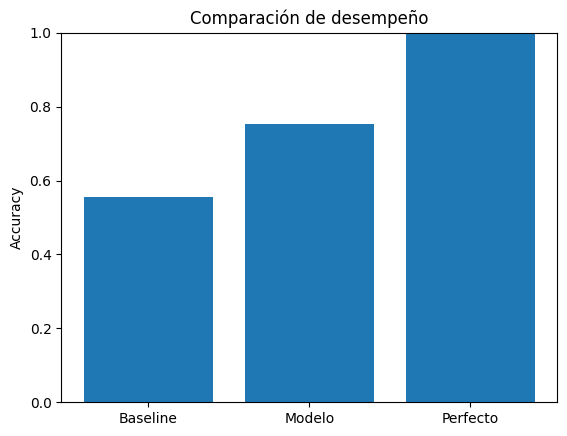

Baseline: 0.5545563549160671
Modelo: 0.7523980815347722


In [103]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Baseline (clase mayoritaria en test)
baseline = y_test.value_counts(normalize=True).max()

# Accuracy modelo (threshold 0.5)
probs = model.predict_proba(X_test_scaled)[:, 1]
preds = (probs > 0.5).astype(int)
model_acc = accuracy_score(y_test, preds)

# Accuracy perfecta (referencia)
perfect = 1.0

plt.figure()
plt.bar(["Baseline", "Modelo", "Perfecto"], [baseline, model_acc, perfect])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparación de desempeño")
plt.show()

print("Baseline:", baseline)
print("Modelo:", model_acc)

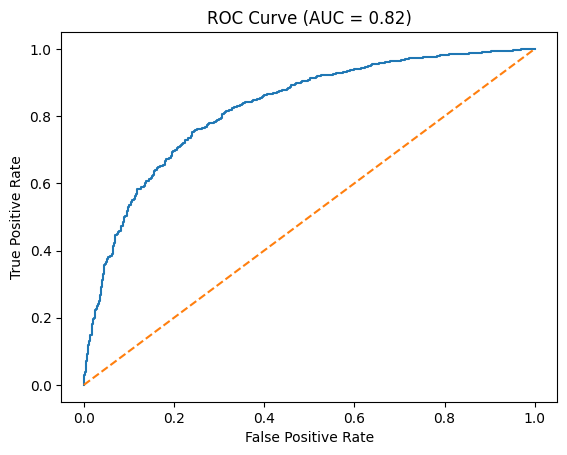

In [104]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()